# Setup

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import sys
from statsmodels import robust
import matplotlib.pyplot as plt
import os.path
import anndata as ad
import seaborn as sns
import matplotlib as mpl
import os
# import scvi


In [2]:
conda env list

# conda environments:
Note: you may need to restart the kernel to use updated packages.

#
                         C:\Users\sambe\AppData\Local\R-MINI~1\envs\r-reticulate
                         C:\Users\sambe\AppData\Local\r-miniconda
base                     C:\Users\sambe\anaconda3
research23            *  C:\Users\sambe\anaconda3\envs\research23
test1                    C:\Users\sambe\anaconda3\envs\test1
test2                    C:\Users\sambe\anaconda3\envs\test2



In [3]:
#os.chdir("..\\")
bigdata = 'C:\\Users\\sambe\\Documents\\bigdata\\'
os.getcwd()

'C:\\Users\\sambe\\OneDrive - Newcastle University\\Research projects\\python\\scripts'

In [4]:
pan_immune_bcells = sc.read(bigdata + "pan_immune_bcells.h5ad")
display(pan_immune_bcells)
#pan_immune_pcells = sc.read(bigdata + "pan_immune_pcells.h5ad")
#display(pan_immune_pcells)
#pan_stroma_cells  = sc.read(bigdata + "pan_stroma_cells.h5ad")
#display(pan_stroma_cells)

AnnData object with n_obs × n_vars = 63942 × 33538
    obs: 'n_counts', 'n_genes', 'file', 'mito', 'doublet_scores', 'predicted_doublets', 'old_annotation_uniform', 'organ', 'Sort_id', 'age', 'method', 'donor', 'sex', 'Sample', 'scvi_clusters', 'is_maternal_contaminant', 'anno_lvl_2_final_clean', 'celltype_annotation'
    var: 'GeneID', 'GeneName', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'scvi_model_var'

# preprocessing

##### Test

In [5]:
pan_immune_bcells.X.toarray()


array([[0., 0., 2., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 2., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [6]:
display(pan_immune_bcells.var)
display(pan_immune_bcells.obs)

,GeneID,GeneName,highly_variable,means,dispersions,dispersions_norm,scvi_model_var
TSPAN6,ENSG00000000003,TSPAN6,False,4.035925e-01,3.192145,-0.068286,False
TNMD,ENSG00000000005,TNMD,True,1.584207e-03,3.603207,1.060200,True
DPM1,ENSG00000000419,DPM1,False,1.788998e+00,3.008108,-0.570585,False
SCYL3,ENSG00000000457,SCYL3,False,6.861534e-01,3.088048,-0.256646,False
C1orf112,ENSG00000000460,C1orf112,False,7.675063e-01,2.918053,-0.564248,False
...,...,...,...,...,...,...,...
AL356417.3,ENSG00000285492,AL356417.3,True,4.720252e-02,3.378242,0.621048,True
AC010616.2,ENSG00000285505,AC010616.2,False,1.601228e-04,3.025356,-0.067820,False
AL034430.1,ENSG00000285508,AL034430.1,False,1.000000e-12,NaN,0.000000,False
AP000646.1,ENSG00000285509,AP000646.1,False,2.194406e-03,2.850603,-0.408955,False


,n_counts,n_genes,file,mito,doublet_scores,predicted_doublets,old_annotation_uniform,organ,Sort_id,age,method,donor,sex,Sample,scvi_clusters,is_maternal_contaminant,anno_lvl_2_final_clean,celltype_annotation
index,,,,,,,,,,,,,,,,,,
FCAImmP7579224-CTAATGGCACTGTGTA,51305.0,5492,FCAImmP7579224,0.046467,0.176471,False,nan,SK,CD45P,12,5GEX,F45,female,F45_SK_CD45P_FCAImmP7579224,6,False,LARGE_PRE_B,LARGE_PRE_B
FCAImmP7579224-TCTTTCCCAAGCCGTC,28616.0,5176,FCAImmP7579224,0.035994,0.152941,False,B CELL,SK,CD45P,12,5GEX,F45,female,F45_SK_CD45P_FCAImmP7579224,10,False,PRE_PRO_B,PRE_PRO_B
FCAImmP7579224-GTATCTTAGCGACGTA,28053.0,4845,FCAImmP7579224,0.033651,0.125320,False,B CELL,SK,CD45P,12,5GEX,F45,female,F45_SK_CD45P_FCAImmP7579224,10,False,PRO_B,PRO_B
FCAImmP7579224-CCCAATCAGCCACGCT,24567.0,3813,FCAImmP7579224,0.038100,0.133690,False,B CELL,SK,CD45P,12,5GEX,F45,female,F45_SK_CD45P_FCAImmP7579224,10,False,PRO_B,PRO_B
FCAImmP7579224-GGAATAATCAGGTAAA,20510.0,4007,FCAImmP7579224,0.044174,0.133690,False,B CELL,SK,CD45P,12,5GEX,F45,female,F45_SK_CD45P_FCAImmP7579224,26,False,PRE_PRO_B,PRE_PRO_B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FCAImmP7277565-TAGTTGGTCTCTGTCG,2378.0,928,FCAImmP7277565,0.045416,0.081340,False,B CELL,TH,CD45N,14,3GEX,F30,male,F30_TH_CD45N_FCAImmP7277565,11,False,SMALL_PRE_B,SMALL_PRE_B
FCAImmP7277565-CAGGTGCAGACGCAAC,2252.0,885,FCAImmP7277565,0.015098,0.098390,False,PRE PRO B CELL,TH,CD45N,14,3GEX,F30,male,F30_TH_CD45N_FCAImmP7277565,11,False,SMALL_PRE_B,SMALL_PRE_B
FCAImmP7277565-GTGCAGCAGAGCTGGT,2115.0,1005,FCAImmP7277565,0.017021,0.089376,False,PRE PRO B CELL,TH,CD45N,14,3GEX,F30,male,F30_TH_CD45N_FCAImmP7277565,15,False,LATE_PRO_B,LATE_PRO_B


##### SC quality control

In [5]:
# mitochondrial genes
pan_immune_bcells.var["mt"] = pan_immune_bcells.var_names.str.startswith("MT-")
# ribosomal genes
pan_immune_bcells.var["ribo"] = pan_immune_bcells.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
pan_immune_bcells.var["hb"] = pan_immune_bcells.var_names.str.contains(("^HB[^(P)]"))

# why filter hb and ribp

In [6]:
sc.pp.calculate_qc_metrics(
    pan_immune_bcells, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)

In [7]:
display(pan_immune_bcells.var)
display(pan_immune_bcells.obs)

,GeneID,GeneName,highly_variable,means,dispersions,dispersions_norm,scvi_model_var
TSPAN6,ENSG00000000003,TSPAN6,False,4.035925e-01,3.192145,-0.068286,False
TNMD,ENSG00000000005,TNMD,True,1.584207e-03,3.603207,1.060200,True
DPM1,ENSG00000000419,DPM1,False,1.788998e+00,3.008108,-0.570585,False
SCYL3,ENSG00000000457,SCYL3,False,6.861534e-01,3.088048,-0.256646,False
C1orf112,ENSG00000000460,C1orf112,False,7.675063e-01,2.918053,-0.564248,False
...,...,...,...,...,...,...,...
AL356417.3,ENSG00000285492,AL356417.3,True,4.720252e-02,3.378242,0.621048,True
AC010616.2,ENSG00000285505,AC010616.2,False,1.601228e-04,3.025356,-0.067820,False
AL034430.1,ENSG00000285508,AL034430.1,False,1.000000e-12,NaN,0.000000,False
AP000646.1,ENSG00000285509,AP000646.1,False,2.194406e-03,2.850603,-0.408955,False


,n_counts,n_genes,file,mito,doublet_scores,predicted_doublets,old_annotation_uniform,organ,Sort_id,age,method,donor,sex,Sample,scvi_clusters,is_maternal_contaminant,anno_lvl_2_final_clean,celltype_annotation
index,,,,,,,,,,,,,,,,,,
FCAImmP7579224-CTAATGGCACTGTGTA,51305.0,5492,FCAImmP7579224,0.046467,0.176471,False,nan,SK,CD45P,12,5GEX,F45,female,F45_SK_CD45P_FCAImmP7579224,6,False,LARGE_PRE_B,LARGE_PRE_B
FCAImmP7579224-TCTTTCCCAAGCCGTC,28616.0,5176,FCAImmP7579224,0.035994,0.152941,False,B CELL,SK,CD45P,12,5GEX,F45,female,F45_SK_CD45P_FCAImmP7579224,10,False,PRE_PRO_B,PRE_PRO_B
FCAImmP7579224-GTATCTTAGCGACGTA,28053.0,4845,FCAImmP7579224,0.033651,0.125320,False,B CELL,SK,CD45P,12,5GEX,F45,female,F45_SK_CD45P_FCAImmP7579224,10,False,PRO_B,PRO_B
FCAImmP7579224-CCCAATCAGCCACGCT,24567.0,3813,FCAImmP7579224,0.038100,0.133690,False,B CELL,SK,CD45P,12,5GEX,F45,female,F45_SK_CD45P_FCAImmP7579224,10,False,PRO_B,PRO_B
FCAImmP7579224-GGAATAATCAGGTAAA,20510.0,4007,FCAImmP7579224,0.044174,0.133690,False,B CELL,SK,CD45P,12,5GEX,F45,female,F45_SK_CD45P_FCAImmP7579224,26,False,PRE_PRO_B,PRE_PRO_B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FCAImmP7277565-TAGTTGGTCTCTGTCG,2378.0,928,FCAImmP7277565,0.045416,0.081340,False,B CELL,TH,CD45N,14,3GEX,F30,male,F30_TH_CD45N_FCAImmP7277565,11,False,SMALL_PRE_B,SMALL_PRE_B
FCAImmP7277565-CAGGTGCAGACGCAAC,2252.0,885,FCAImmP7277565,0.015098,0.098390,False,PRE PRO B CELL,TH,CD45N,14,3GEX,F30,male,F30_TH_CD45N_FCAImmP7277565,11,False,SMALL_PRE_B,SMALL_PRE_B
FCAImmP7277565-GTGCAGCAGAGCTGGT,2115.0,1005,FCAImmP7277565,0.017021,0.089376,False,PRE PRO B CELL,TH,CD45N,14,3GEX,F30,male,F30_TH_CD45N_FCAImmP7277565,15,False,LATE_PRO_B,LATE_PRO_B


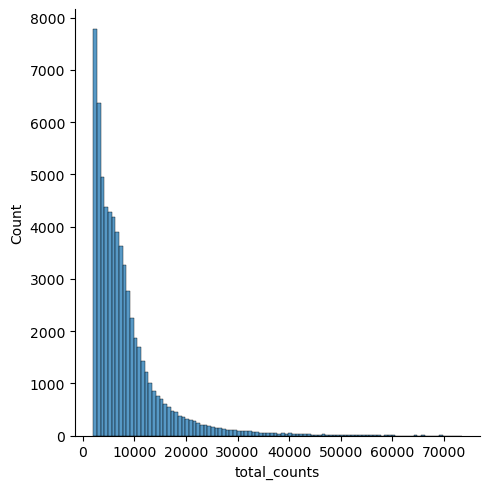

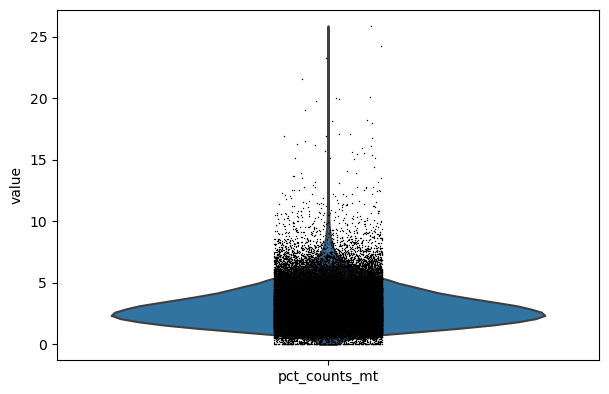

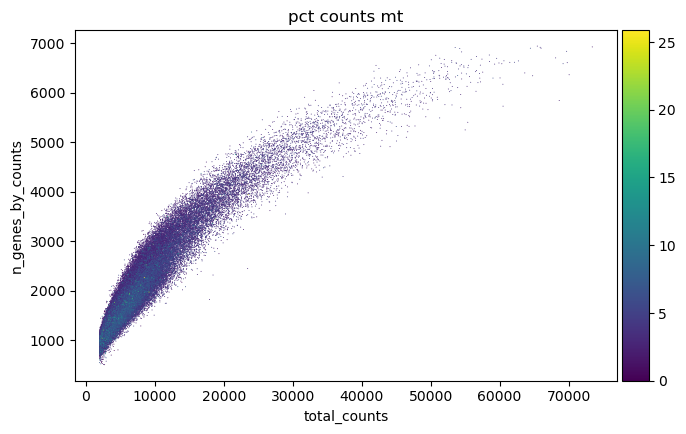

In [11]:
p1 = sns.displot(pan_immune_bcells.obs["total_counts"], bins=100, kde=False)
# sc.pl.violin(pan_immune_bcells, 'total_counts')
p2 = sc.pl.violin(pan_immune_bcells, "pct_counts_mt")
p3 = sc.pl.scatter(pan_immune_bcells, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

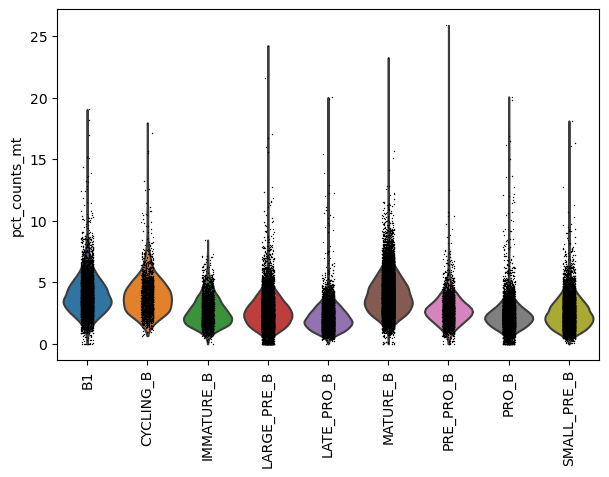

In [33]:
p2 = sc.pl.violin(pan_immune_bcells, "pct_counts_mt", groupby='anno_lvl_2_final_clean', rotation=90)

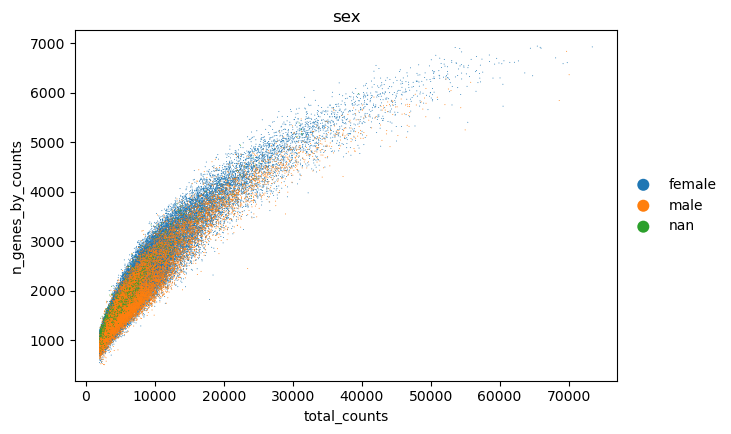

In [10]:
 sc.pl.scatter(pan_immune_bcells, "total_counts", "n_genes_by_counts", color="sex")

##### ambient RNA, doublets, and mitocondrial

In [11]:
sc.pp.calculate_qc_metrics(pan_immune_bcells)

(                                 n_genes_by_counts  log1p_n_genes_by_counts  \
 index                                                                         
 FCAImmP7579224-CTAATGGCACTGTGTA               5492                 8.611230   
 FCAImmP7579224-TCTTTCCCAAGCCGTC               5176                 8.551981   
 FCAImmP7579224-GTATCTTAGCGACGTA               4845                 8.485909   
 FCAImmP7579224-CCCAATCAGCCACGCT               3813                 8.246434   
 FCAImmP7579224-GGAATAATCAGGTAAA               4007                 8.296048   
 ...                                            ...                      ...   
 FCAImmP7277565-TAGTTGGTCTCTGTCG                928                 6.834109   
 FCAImmP7277565-CAGGTGCAGACGCAAC                885                 6.786717   
 FCAImmP7277565-GTGCAGCAGAGCTGGT               1005                 6.913737   
 FCAImmP7277565-TACTCGCCACGTCTCT                994                 6.902743   
 FCAImmP7277565-GAACATCGTACCAGTT        

In [12]:
sc.pp.filter_cells(pan_immune_bcells, min_genes=200)
sc.pp.filter_genes(pan_immune_bcells, min_cells=3)

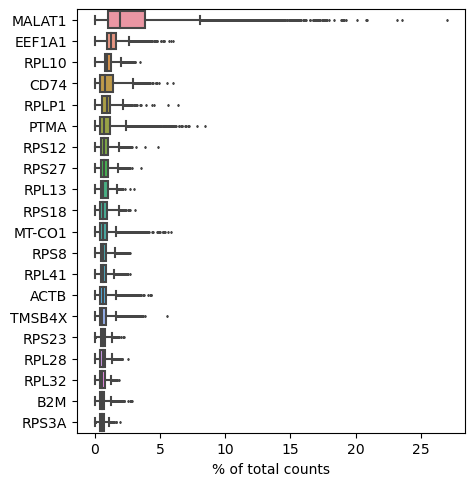

In [13]:
sc.pl.highest_expr_genes(pan_immune_bcells, n_top=20, )


In [14]:
pan_immune_bcells.var['mt'] = pan_immune_bcells.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(pan_immune_bcells, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

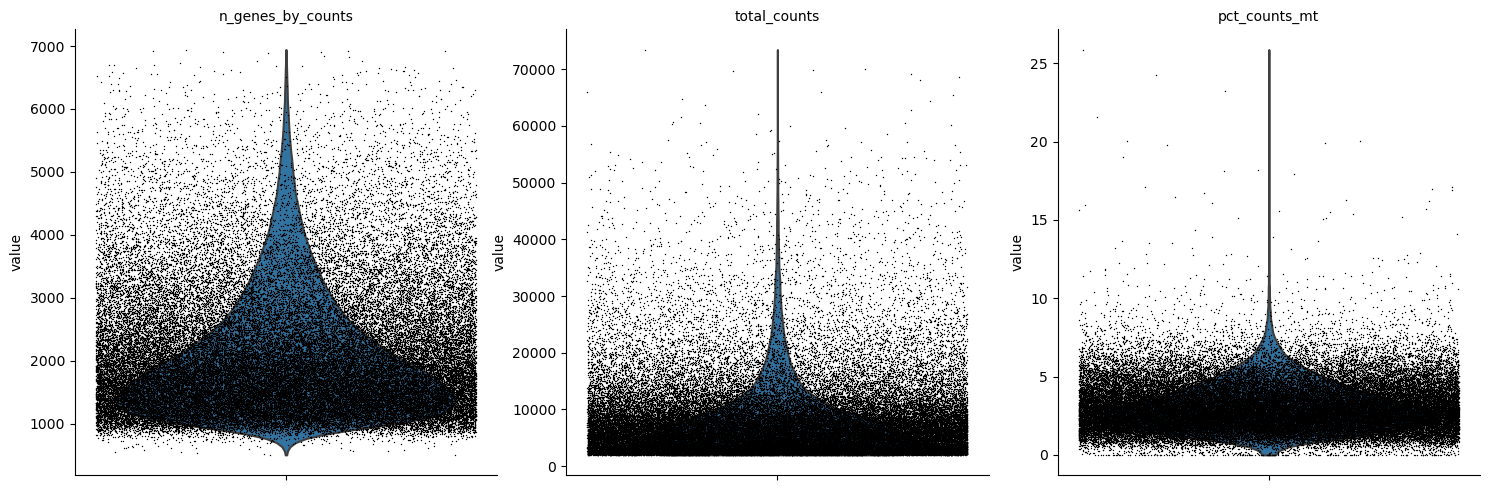

In [31]:
sc.pl.violin(pan_immune_bcells, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.45, multi_panel=True)

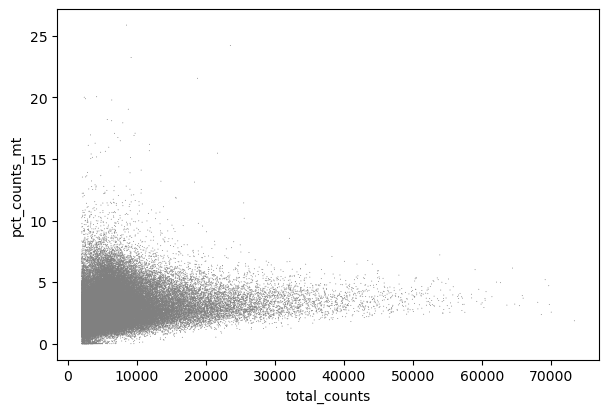

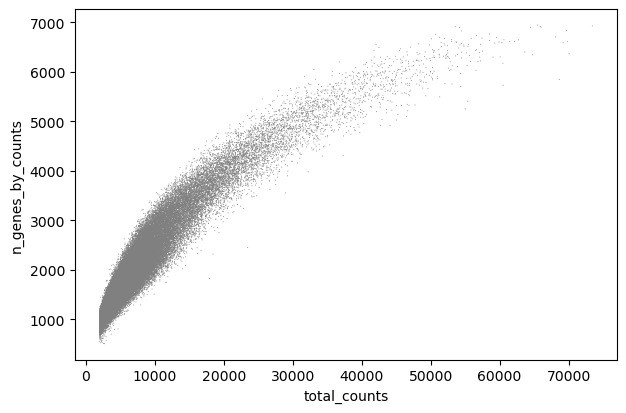

In [16]:
sc.pl.scatter(pan_immune_bcells, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(pan_immune_bcells, x='total_counts', y='n_genes_by_counts')

In [17]:
sc.pp.normalize_total(pan_immune_bcells, target_sum=1e4)


In [18]:
sc.pp.log1p(pan_immune_bcells)


In [19]:
sc.pp.highly_variable_genes(pan_immune_bcells, min_mean=0.0125, max_mean=3, min_disp=0.5)

In [42]:
sc.pl.highly_variable_genes(pan_immune_bcells)


KeyError: 'hvg'

In [21]:
pan_immune_bcells.raw = pan_immune_bcells


In [22]:
pan_immune_bcells = pan_immune_bcells[:, pan_immune_bcells.var.highly_variable]


In [23]:
sc.pp.regress_out(pan_immune_bcells, ['total_counts', 'pct_counts_mt'])


In [24]:
sc.pp.scale(pan_immune_bcells, max_value=10)


In [25]:
sc.tl.pca(pan_immune_bcells, svd_solver='arpack')


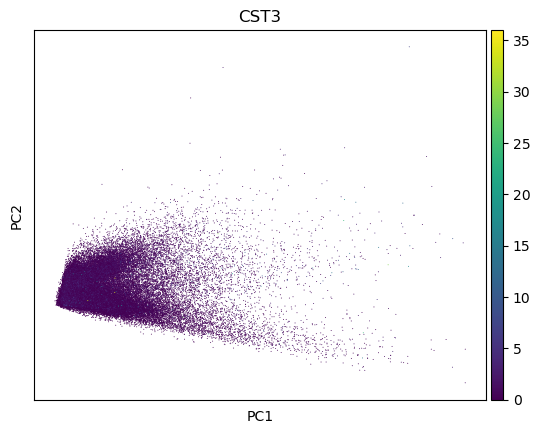

In [40]:
sc.pl.pca(pan_immune_bcells, color='CST3')


In [41]:
sc.pl.pca_variance_ratio(pan_immune_bcells, log=True)


KeyError: 'pca'

In [35]:
sc.pp.neighbors(pan_immune_bcells, n_neighbors=10, n_pcs=20)

In [36]:
sc.tl.umap(pan_immune_bcells)


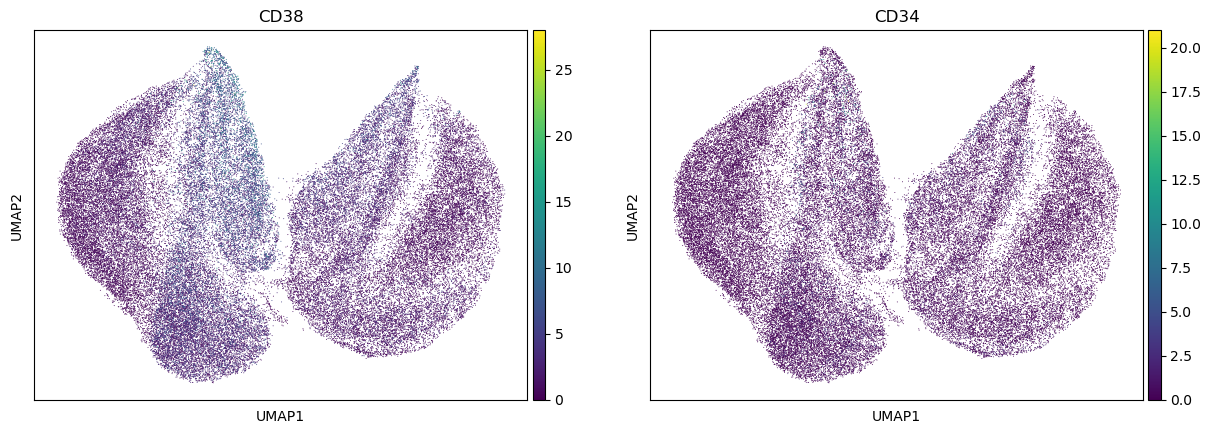

In [37]:
sc.pl.umap(pan_immune_bcells, color=['CD38', 'CD34'], use_raw=False)
#CD19, CD 20, CD34, CD38, and CD45R
# just threw in some B cell markers because its more applicable.